# Bootstrapping

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## 1. IID Sequences and Sampling Distribution

## Independent and Identically Distributed Sequences (iid)
- A fundamental concept in probability and statistics is the abstract idea of running an "experiment" over and over, and computing statistics for the results
- Let $x_1$ be the result of the first experiment, $x_2$ the result of the second, and so on
- Assume that the draws $x_1, x_2, ...$ 
  - are **identically distributed**: They are all drawn from the same distribution function and all have the same mean $\mu$ and variance $\sigma^2$
  - are **independent**: The outcome of draw $x_n$ doesn't affect the outcome of any draw $x_m$, $m \neq n$ (in the sense of conditioning)

## Example: Not iid
- To appreciate iid, let's look at something that is not iid
- An **autoregressive-1 process** is 
$$
y_{t} = \alpha + \rho y_{t-1} + \sigma \varepsilon_t
$$
where $\varepsilon_t$ is iid with mean 0 and standard deviation 1
- An AR-$K$ process uses more lagged values:
$$
y_{t} = \alpha + \sum_{k=1}^K \rho_k y_{t-k} + \sigma \varepsilon_t
$$

In [48]:
def ar1sim(rho=0.8):
    rng = np.random.default_rng(100)

    # Parameters
    T = 200
    alpha = 1.0
    sigma = 1.0
    initial = 10

    # Simulate innovations
    eps = rng.normal(size=T + initial)

    # Simulate AR(1)
    y = np.zeros(T + initial)
    for t in range(1, T + initial):
        y[t] = alpha + rho * y[t - 1] + sigma * eps[t]
    y = y[initial:]

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Time series plot
    ax[0].plot(y)
    ax[0].set_xlabel("t")
    ax[0].set_ylabel(r"$y_t$")
    ax[0].set_title(
        rf"AR(1): $\alpha={alpha}$, $\rho={rho}$, $\sigma={sigma}$"
    )

    # Lag plot
    ax[1].scatter(y[:-1], y[1:], alpha=0.6)
    ax[1].set_xlabel(r"$y_t$")
    ax[1].set_ylabel(r"$y_{t+1}$")
    ax[1].set_title(r"$y_{t+1}$ versus $y_t$")

    plt.tight_layout()
    plt.show()

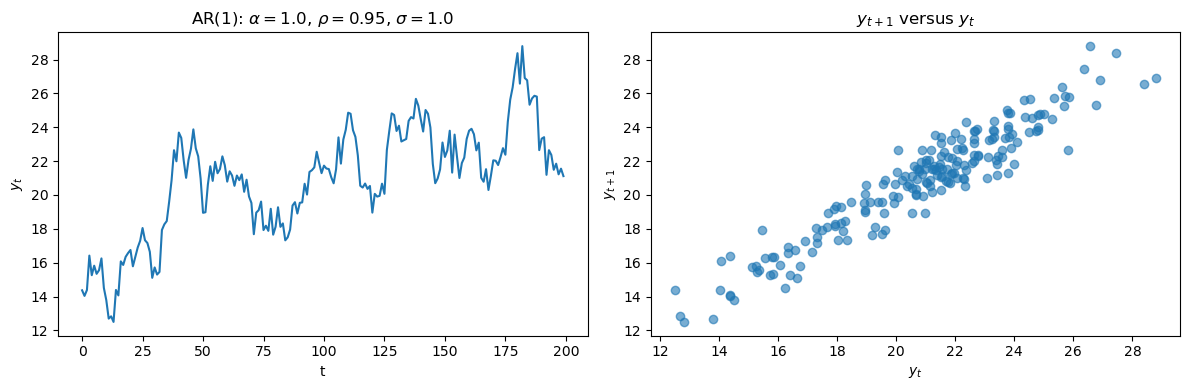

In [49]:
ar1sim(.95)

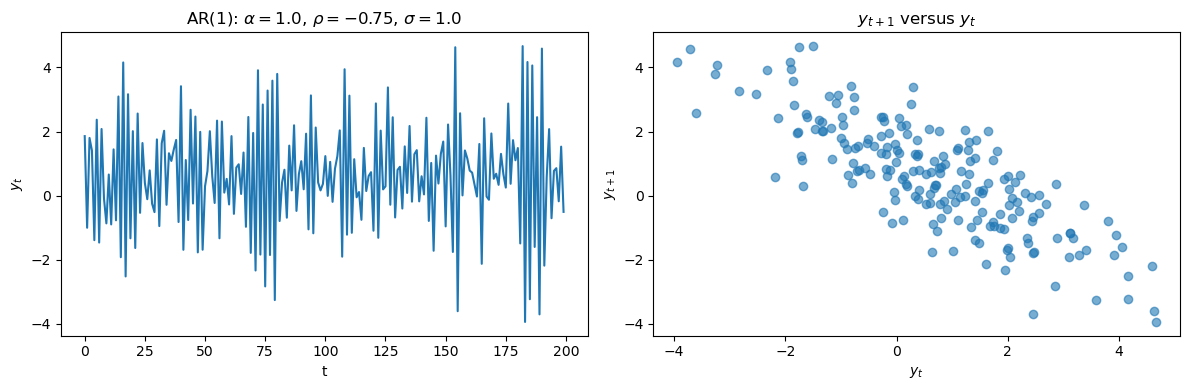

In [50]:
ar1sim(-.75)

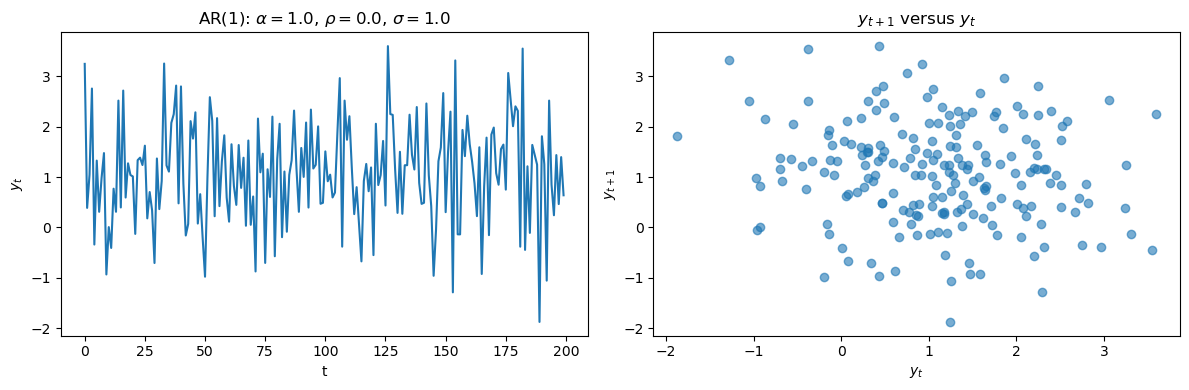

In [51]:
ar1sim(0.0)

## Autocovariance of the AR1
$$
\begin{alignat*}{2}
\text{cov}(Y_{t-1}, Y_{t}) &=& \text{cov}(Y_{t-1}, \alpha + \rho Y_{t-1} + \sigma \varepsilon_{t} )
\\
&=& \text{cov}(Y_{t-1}, \alpha) + \text{cov}(Y_{t-1},\rho Y_{t-1}) + \text{cov}(Y_{t-1},\sigma \varepsilon_{t} )\\
&=& 0 + \rho \text{cov}(Y_{t-1},Y_{t-1})+ 0 \\
&=& \rho \mathbb{V}[Y_{t-1}]
\end{alignat*}
$$
- If $\rho=0$, then $Y_t=\alpha+\sigma\varepsilon_t$ is iid when the innovations are iid; after subtracting its mean $\alpha$, it is a **white noise process**

## Statistics and Sampling Distribution
- Imagine we have an IID sequence, and we want to learn about it (learning about non-iid sequences happens later with time series and panel data)
- A **statistic** $S$ is any function of the sample data, like the sample mean or regression coefficients or $R^2$ or a prediction
- They are themselves random variables, mapping the underlying probability space associated with the data into numbers
- When the data are IID, how does this quantity behave?
- We call the distribution of a statistic its **sampling distribution**

## Example: Linear Regression
- Suppose the model is
$$
y_i = 1.0 - 2.0 \times x_i + \sigma \varepsilon_i
$$
where $\mathbb{E}[\varepsilon_i|x_i]=0$ and $\mathbb{E}[\varepsilon_i^2|x_i]=1$
- The slope coefficient is
$$
\hat{\beta} = \dfrac{(x-\bar{x})\cdot(y-\bar{y})}{(x-\bar{x})\cdot(x-\bar{x})} \approx \dfrac{\text{cov}(X,Y)}{\text{var}(X)}
$$
- You can do the same procedure with multiple linear regression, using
$$
\hat{\beta} = [ (X-\bar{X})^{\top}(X-\bar{X}) ]^{-1} [(X-\bar{X})^{\top}(Y-\bar{Y})] \approx C_{X,X}^{-1} C_{X,Y}
$$ 

In [52]:
def gen_data(N = 10_000):
    ## Parameters
    a = 1.0
    b = -2.0
    sigma = np.sqrt(7.0)
    cov = np.array( [[5.0, 0], [0, 1.0]])
    ## Generate shocks and explanatory variable
    draws = rng.multivariate_normal( mean = np.array([10,0]), 
                                    cov = cov, size = N )
    X = draws[:,0]
    eps = draws[:,1]
    y = a + b * X + sigma * eps
    ## Send to dataframe
    df = pd.DataFrame( {'X':X, 'y':y })
    return df

def slr(x,y):
    w_x = x - x.mean()
    w_y = y - y.mean()
    beta_hat = np.inner(w_x, w_y) / np.inner(w_x, w_x)
    return beta_hat

In [53]:
rng = np.random.default_rng(100)
R = 10_000
N = 50_000 
results = []
for i in range(R):
    df_i = gen_data(N)
    beta_i = slr( df_i['X'], df_i['y'])
    results.append(beta_i)
results = np.array(results)

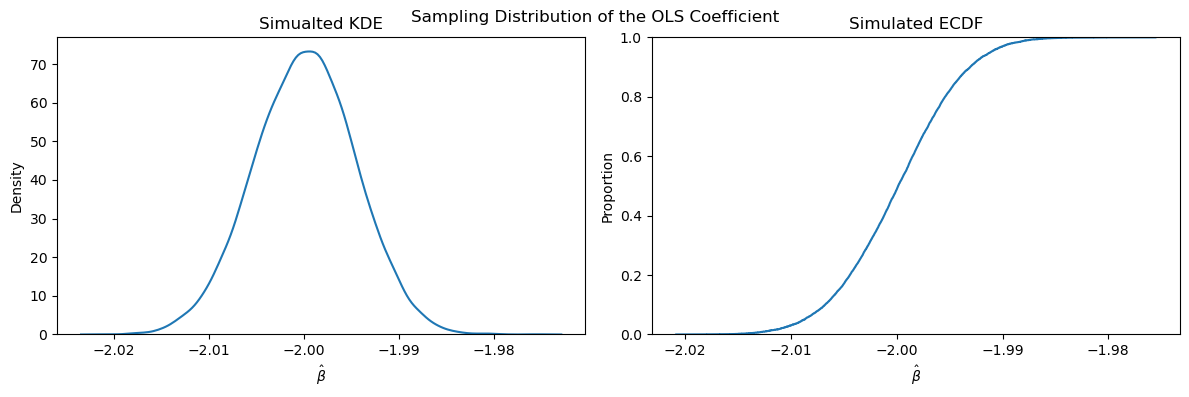

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# KDE
sns.kdeplot(results, ax=ax[0])
ax[0].set_xlabel(r"$\hat{\beta}$")
ax[0].set_title("Simulated KDE")
# ECDF
sns.ecdfplot(results, ax=ax[1])
ax[1].set_xlabel(r"$\hat{\beta}$")
ax[1].set_title("Simulated ECDF")
plt.tight_layout()
fig.suptitle('Sampling Distribution of the OLS Coefficient')
plt.show()

## Sampling Distribution
- Asymptotic statistics is generally about deriving the distribution of a statistic as the sample size gets large
- The Central Limit Theorem says, roughly, that the above picture should be a normal distribution with a mean around the truth, and a variance tending towards zero
- Asymptotic approximations remain central to statistical inference; resampling methods such as the jackknife, cross-validation, and bootstrap provide complementary, computational approaches
- **The standard deviation of the sampling distribution is called the standard error**

# 2. The Bootstrap

## Bootstrapping
- As data scientists, we typically can't run more experiments or get more observations: The data are often all we get
- How can we "simulate" the experiment many times, to learn about the sampling distribution of our statistic/parameters/predictions?
- Big Idea: **If the data are iid** and **sampled at random** from the underlying data generation process, then we can **resample (with replacement)** our data to simulate drawing a new sample from the original data generating process

## Bootstrapping the Sampling Distribution
- Fix a bootstrap replication value $R$.

1. For $t$ in $1, ..., R$,
    - Draw a sample of $n$ observations from your data with replacement, $D_t$
    - Compute the statistic for this sample, $\hat{S}_t = S(D_t)$
2. The collection $[\hat{S}_1, ..., \hat{S}_R]$ then approximates the sampling distribution of $\hat{S}$

Using the collection $[\hat{S}_1, ..., \hat{S}_R]$, we can:
- Compute the ECDF, which is an estimator of the sampling distribution
- Compute the KDE, which is an estimator of the sampling density
- Compute the standard deviation, which is the standard error of $\hat{S}$


## Example: Linear Regression
- Let's run a single linear regression of heart failure on heart rate, and bootstrap the sampling distribution of the coefficient from the data

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/CardiacPatientData.csv')
df.head()

,ID,SBP,DBP,HR,RR,BT,SpO2,Age,Gender,GCS,Na,K,Cl,Urea,Ceratinine,Alcoholic,Smoke,FHCD,TriageScore,Outcome
0,1,163,95,90,18,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1
1,1,134,85,85,15,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1
2,1,121,77,80,19,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1
3,1,103,78,70,16,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1
4,1,96,70,59,13,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1


In [56]:
df = df.loc[:,['HR','Outcome']].dropna()
y = df['Outcome']
x = df['HR']

def slr(x,y):
    w_x = x - x.mean()
    w_y = y - y.mean()
    beta_hat = np.inner(w_x, w_y) / np.inner(w_x, w_x)
    return beta_hat

beta_hat = slr(x,y)
print(f'The slr coefficient is: {beta_hat:.3f}')

The slr coefficient is: -0.008


In [57]:
R = 5000
replications = []
for r in range(R):
    df_r = df.sample( frac = 1.0, replace = True )
    y_r = df_r['Outcome']
    x_r = df_r['HR']
    beta_r = slr(x_r, y_r)
    replications.append(beta_r)
replications = np.array(replications)

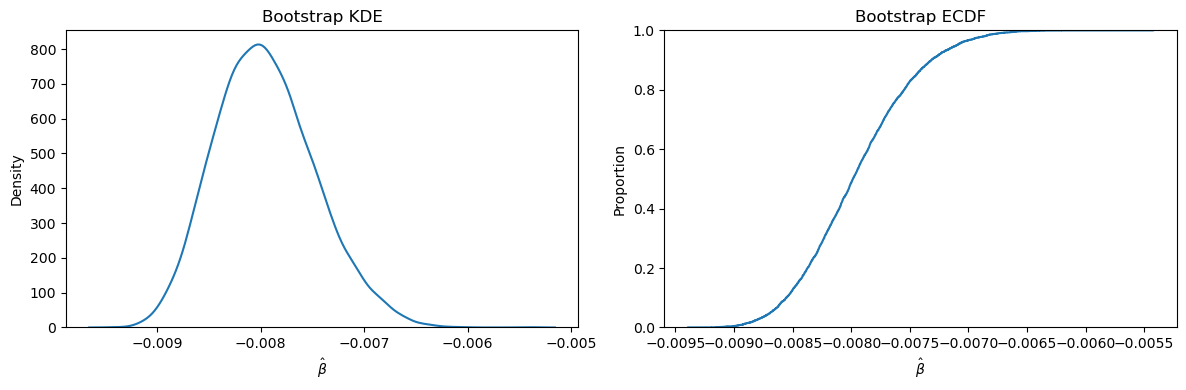

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# KDE
sns.kdeplot(replications, ax=ax[0])
ax[0].set_xlabel(r"$\hat{\beta}$")
ax[0].set_title("Bootstrap KDE")
# ECDF
sns.ecdfplot(replications, ax=ax[1])
ax[1].set_xlabel(r"$\hat{\beta}$")
ax[1].set_title("Bootstrap ECDF")
plt.tight_layout()
plt.show()

## Bootstrapping

- This version (non-parametric bootstrap) is appropriate if the data are IID; otherwise there are other flavors (block bootstrap, wild bootstrap) to account for spatial or temporal correlation
- For now, the KDE/ECDF plots are the answer: We can quantify the uncertainty associated with our estimates

## The Variation in Data
- As it turns out, there is an enormous amount of variation in your data
- There are $10^{80}$ atoms in the universe, $10^{11}$ stars in an average galaxy, and $10^{12}$ galaxies in the observable universe; these are inconceivably large numbers
- If you have a dataset with $N$ rows, how many ways are there to draw the first replicate? $N$. The second? $N$. And so on. 
- There are $N^N$ ways to resample your data, with replacement.
- If $N=100$, there are $100^{100}$ ways to resample it, greater than the number of stars in an average galaxy, the number of galaxies in the observable universe, and even the number of atoms
- It is not credible that we can exhaust the number of ways to resample a dataset, even on the most powerful computers we have, with even moderately large datasets

## Communicating Results
- The distribution of the bootstrap replicates estimates the sampling distribution of the statistic
- A common numeric summary is the **percentile bootstrap confidence interval**, whose endpoints are selected quantiles of the bootstrap replicates
- This interval quantifies uncertainty about the underlying parameter, subject to the assumptions of the bootstrap procedure

In [59]:
def ci(replications, title=None):
    # Percentile bootstrap confidence intervals
    ci90 = np.quantile(replications, [.05, .95])
    ci95 = np.quantile(replications, [.025, .975])
    ci99 = np.quantile(replications, [.005, .995])

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ## KDE
    sns.kdeplot(replications, ax=ax[0])

    ax[0].axvspan(ci99[0], ci99[1], alpha=0.10, label="99% CI")
    ax[0].axvspan(ci95[0], ci95[1], alpha=0.15, label="95% CI")
    ax[0].axvspan(ci90[0], ci90[1], alpha=0.20, label="90% CI")

    ax[0].set_xlabel(r"$\hat{\beta}$")
    ax[0].set_title("Bootstrap KDE")
    ax[0].legend()

    ## ECDF
    sns.ecdfplot(replications, ax=ax[1])

    ax[1].axvspan(ci99[0], ci99[1], alpha=0.10, label="99% CI")
    ax[1].axvspan(ci95[0], ci95[1], alpha=0.15, label="95% CI")
    ax[1].axvspan(ci90[0], ci90[1], alpha=0.20, label="90% CI")

    ax[1].set_xlabel(r"$\hat{\beta}$")
    ax[1].set_title("Bootstrap ECDF")
    ax[1].legend()

    if title is not None:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()

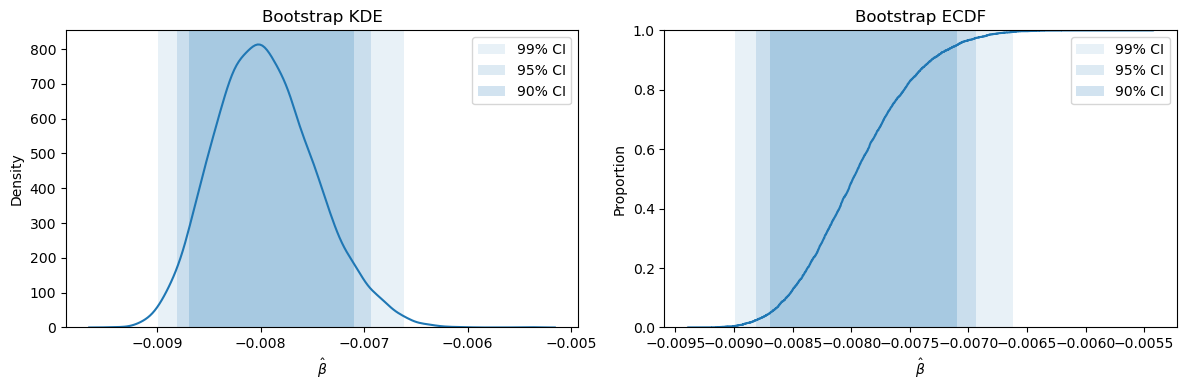

In [60]:
ci(replications)

## Percentile Bootstrap Confidence Intervals

- We typically focus on three cases:
    - The 90% confidence interval uses the .05 and .95 quantiles ($\alpha = .10$) of the bootstrap sample $[\hat{S}_1, ..., \hat{S}_R]$
    - The 95% confidence interval uses the .025 and .975 quantiles ($\alpha = .05$) of the bootstrap sample $[\hat{S}_1, ..., \hat{S}_R]$
    - The 99% confidence interval uses the .005 and .995 quantiles ($\alpha = .01$) of the bootstrap sample $[\hat{S}_1, ..., \hat{S}_R]$

- The parameter $\alpha$ is the **significance level**. To construct a two-sided percentile bootstrap $(1-\alpha)$ confidence interval:
    1. Find the $\alpha/2$ and $1-\alpha/2$ quantiles of $[\hat{S}_1, ..., \hat{S}_R]$, denoted $q_{\alpha/2}$ and $q_{1-\alpha/2}$
    2. Report $(q_{\alpha/2}, q_{1-\alpha/2})$

## Hypothesis Testing
- Let $S_0$ be a hypothesized value of the parameter; often $S_0=0$, but it can be any value
- The **null hypothesis** is $H_0:S=S_0$; for a two-sided test, the **alternative hypothesis** is $H_A:S\neq S_0$
- At significance level $\alpha$, reject $H_0$ when $S_0$ lies outside the corresponding $(1-\alpha)$ confidence interval; otherwise, fail to reject $H_0$
- Failing to reject $H_0$ does not prove that it is true
- Statistical significance is not the same as practical importance: interpret the estimated effect size and confidence interval in context

In [61]:
df = pd.read_csv('./data/CardiacPatientData.csv')

In [62]:
df = df.loc[:,['HR','SpO2','K','Age','Outcome']].dropna()
y = df['Outcome']
X = df.drop(['Outcome'], axis=1)
vars = ['Constant'] + (X.columns).tolist() 
X = np.hstack([np.ones((X.shape[0], 1)), X]) # add intercept
X = np.array(X)

In [63]:
def mlr(X,y):
    XpX = X.T @ X
    XpY = X.T @ y
    beta_hat = np.linalg.solve(XpX, XpY)
    return beta_hat

beta_sample = mlr(X,y)

R = 5000
replications = []
for r in range(R):
    df_r = df.sample( frac = 1.0, replace = True )
    y_r = df_r['Outcome']
    X_r = df_r.drop( ['Outcome'], axis=1)
    X_r = np.hstack([np.ones((X_r.shape[0], 1)), X_r]) # add intercept
    beta_r = mlr(X_r, y_r)
    replications.append(beta_r)
replications = pd.DataFrame(replications, columns = vars)


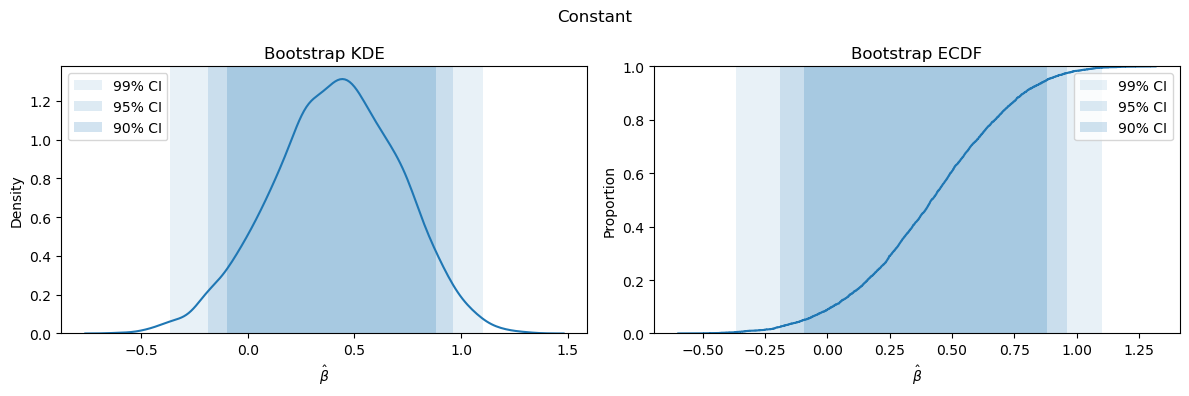

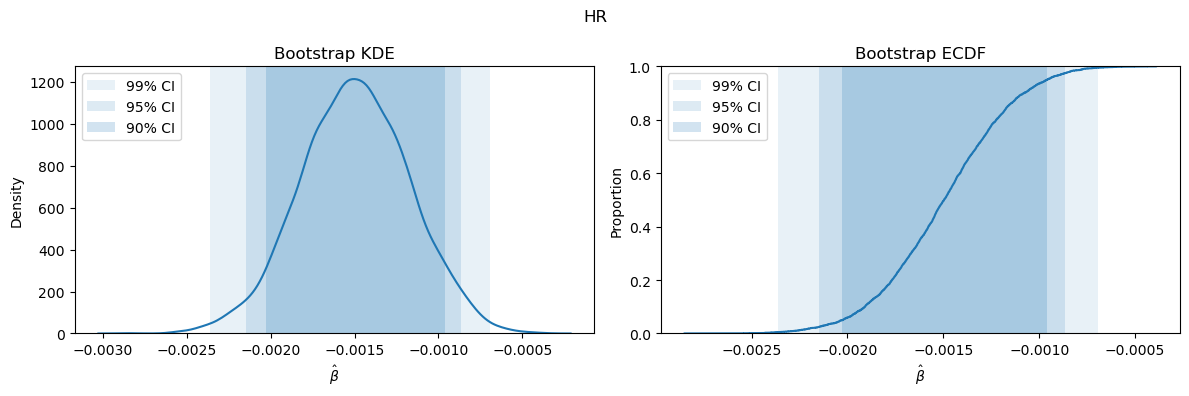

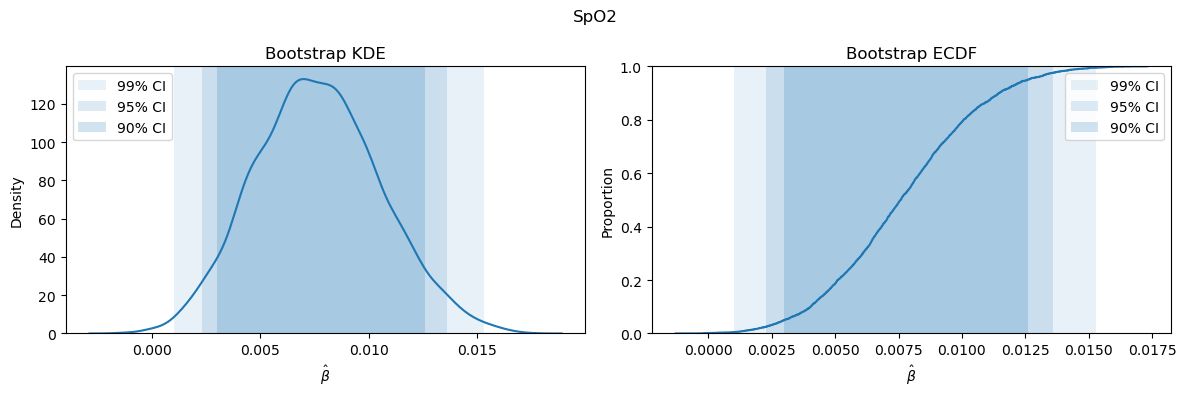

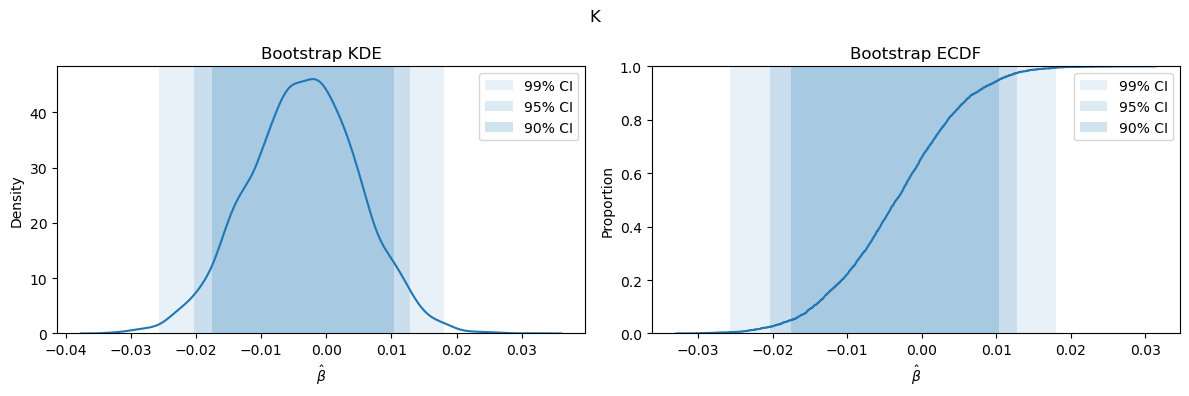

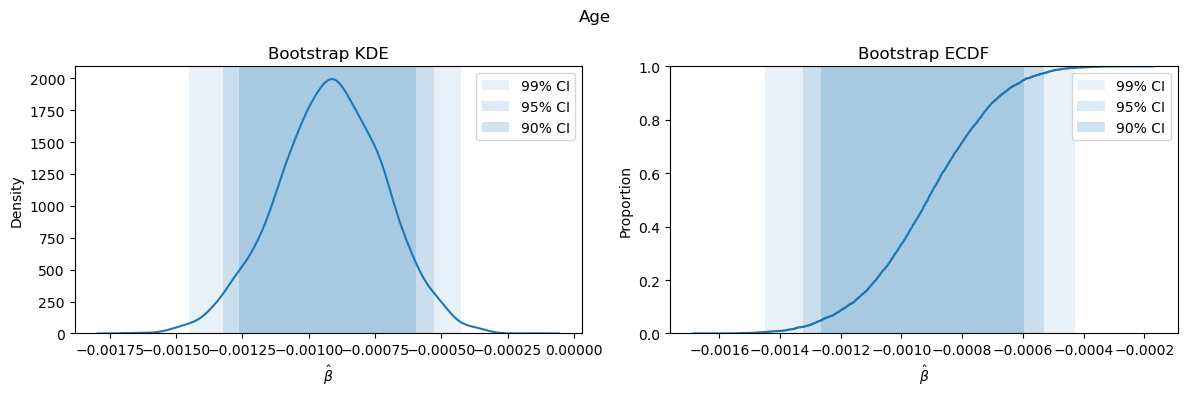

In [64]:
for var in vars:
    vals = replications[var]
    ci(vals, title=var)

- The 90%, 95%, and 99% percentile intervals for `Constant` and `K` include zero, so we fail to reject the corresponding null hypotheses at those significance levels
- The intervals for `HR`, `SpO2`, and `Age` exclude zero, so we reject the corresponding null hypotheses at those significance levels
- These conclusions concern statistical evidence; practical importance depends on the coefficient magnitudes and the variables' units

## Interpreting the Bootstrap and CI

- If we repeatedly drew samples and constructed intervals using the same procedure, approximately 90/95/99% of those intervals would contain the true parameter, under the method's assumptions
- Once a particular frequentist interval has been computed, we do not say that the fixed true value has probability .90/.95/.99 of lying in that interval
- The true value either **is** or **is not** in the observed interval; the confidence level describes the long-run coverage of the procedure
- Frequentist inference studies the sampling behavior of procedures under hypothesized parameter values; Bayesian inference assigns probability distributions to unknown parameters conditional on observed data
- A confidence interval quantifies statistical uncertainty; it is not a truth machine